In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv("../data/raw/KDDTrain+.txt", header=None)

In [12]:
print(df.shape)

(125973, 43)


In [13]:
df.head()

,0,1,2,3,4,5,6,7,8,9,...,33,34,35,36,37,38,39,40,41,42
0,0,tcp,ftp_data,SF,491,0,0,0,0,0,...,0.17,0.03,0.17,0.00,0.00,0.00,0.05,0.00,normal,20
1,0,udp,other,SF,146,0,0,0,0,0,...,0.00,0.60,0.88,0.00,0.00,0.00,0.00,0.00,normal,15
2,0,tcp,private,S0,0,0,0,0,0,0,...,0.10,0.05,0.00,0.00,1.00,1.00,0.00,0.00,neptune,19
3,0,tcp,http,SF,232,8153,0,0,0,0,...,1.00,0.00,0.03,0.04,0.03,0.01,0.00,0.01,normal,21
4,0,tcp,http,SF,199,420,0,0,0,0,...,1.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,normal,21


In [14]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 125973 entries, 0 to 125972
Data columns (total 43 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   0       125973 non-null  int64  
 1   1       125973 non-null  str    
 2   2       125973 non-null  str    
 3   3       125973 non-null  str    
 4   4       125973 non-null  int64  
 5   5       125973 non-null  int64  
 6   6       125973 non-null  int64  
 7   7       125973 non-null  int64  
 8   8       125973 non-null  int64  
 9   9       125973 non-null  int64  
 10  10      125973 non-null  int64  
 11  11      125973 non-null  int64  
 12  12      125973 non-null  int64  
 13  13      125973 non-null  int64  
 14  14      125973 non-null  int64  
 15  15      125973 non-null  int64  
 16  16      125973 non-null  int64  
 17  17      125973 non-null  int64  
 18  18      125973 non-null  int64  
 19  19      125973 non-null  int64  
 20  20      125973 non-null  int64  
 21  21      125973 non-nu

In [15]:
df.isnull().sum()

0     0
1     0
2     0
3     0
4     0
5     0
6     0
7     0
8     0
9     0
10    0
11    0
12    0
13    0
14    0
15    0
16    0
17    0
18    0
19    0
20    0
21    0
22    0
23    0
24    0
25    0
26    0
27    0
28    0
29    0
30    0
31    0
32    0
33    0
34    0
35    0
36    0
37    0
38    0
39    0
40    0
41    0
42    0
dtype: int64

In [16]:
df.duplicated().sum()

np.int64(0)

In [17]:
#Find the Target Column
df.iloc[:, -2].value_counts()

41
normal             67343
neptune            41214
satan               3633
ipsweep             3599
portsweep           2931
smurf               2646
nmap                1493
back                 956
teardrop             892
warezclient          890
pod                  201
guess_passwd          53
buffer_overflow       30
warezmaster           20
land                  18
imap                  11
rootkit               10
loadmodule             9
ftp_write              8
multihop               7
phf                    4
perl                   3
spy                    2
Name: count, dtype: int64

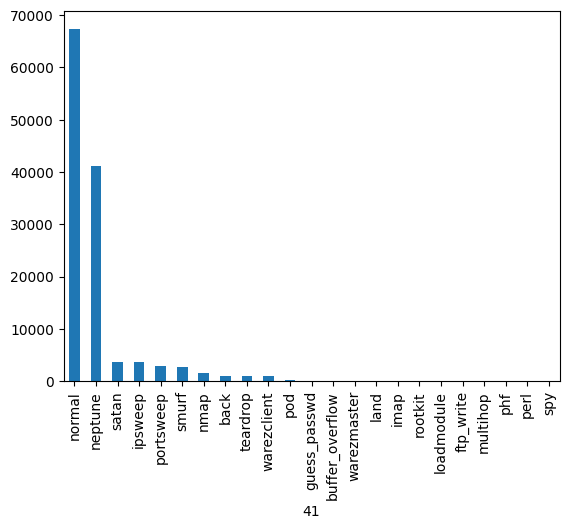

In [19]:
#Class Distribution
df.iloc[:, -2].value_counts().plot(kind="bar")
plt.show()

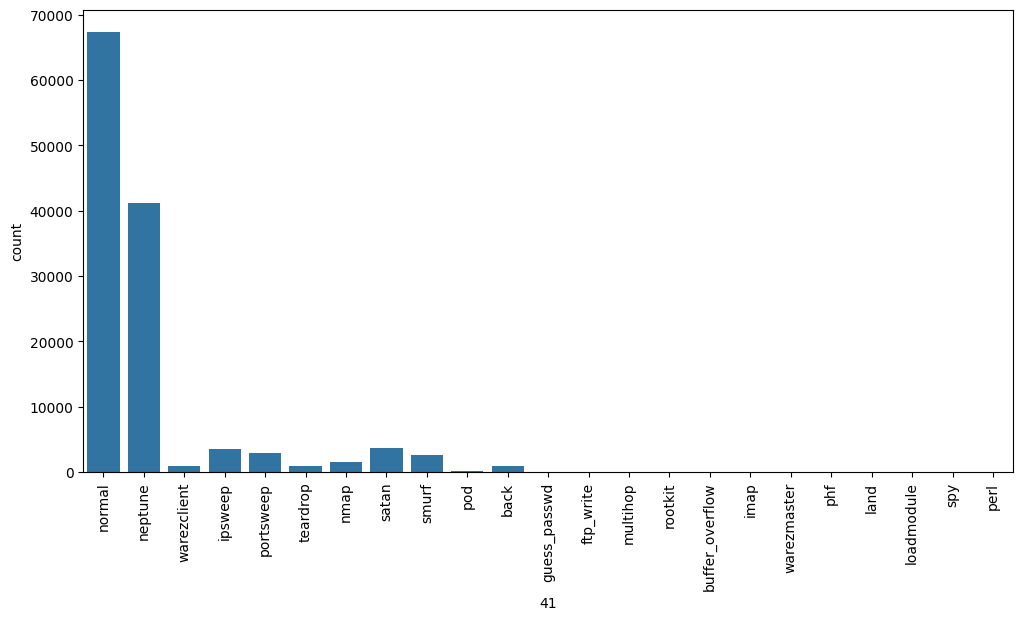

In [22]:
plt.figure(figsize=(12,6))

sns.countplot(
    x=df.iloc[:, -2]
)

plt.xticks(rotation=90)
plt.show()

In [23]:
df.select_dtypes(include="object").columns

c:\temp\ipykernel_27084\1196084386.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  df.select_dtypes(include="object").columns


Index([1, 2, 3, 41], dtype='int64')

In [24]:
df.describe().T

,count,mean,std,min,25%,50%,75%,max
0,125973.0,287.144650,2.604515e+03,0.0,0.00,0.00,0.00,4.290800e+04
4,125973.0,45566.743000,5.870331e+06,0.0,0.00,44.00,276.00,1.379964e+09
5,125973.0,19779.114421,4.021269e+06,0.0,0.00,0.00,516.00,1.309937e+09
6,125973.0,0.000198,1.408607e-02,0.0,0.00,0.00,0.00,1.000000e+00
7,125973.0,0.022687,2.535300e-01,0.0,0.00,0.00,0.00,3.000000e+00
8,125973.0,0.000111,1.436603e-02,0.0,0.00,0.00,0.00,3.000000e+00
9,125973.0,0.204409,2.149968e+00,0.0,0.00,0.00,0.00,7.700000e+01
10,125973.0,0.001222,4.523914e-02,0.0,0.00,0.00,0.00,5.000000e+00
11,125973.0,0.395736,4.890101e-01,0.0,0.00,0.00,1.00,1.000000e+00
12,125973.0,0.279250,2.394204e+01,0.0,0.00,0.00,0.00,7.479000e+03


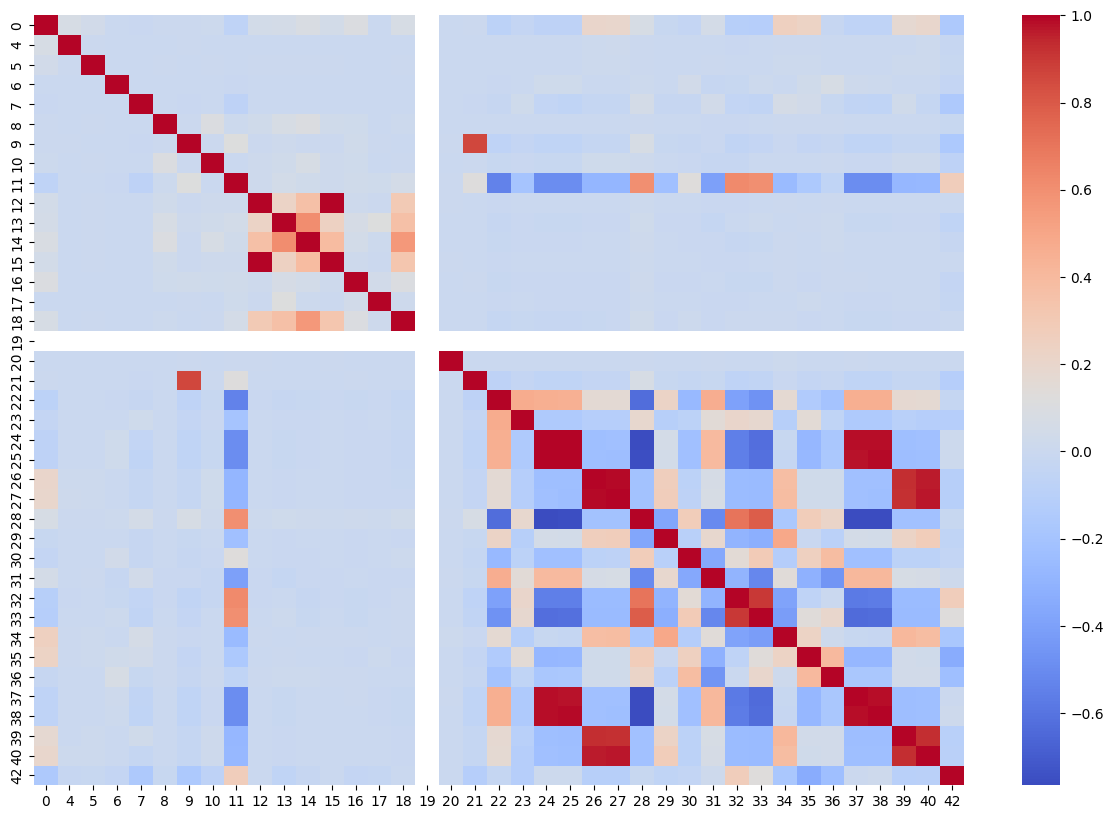

In [25]:
plt.figure(figsize=(15,10))

corr = df.select_dtypes(
    include=np.number
).corr()

sns.heatmap(
    corr,
    cmap="coolwarm"
)

plt.show()